In [1]:
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

dflong = pd.read_csv("tmp_data/KuaiRand-1K/data/log_standard_4_08_to_4_21_1k.csv", nrows=10000000)

In [2]:
dflong

,user_id,video_id,date,hourmin,time_ms,is_click,is_like,is_follow,is_comment,is_forward,is_hate,long_view,play_time_ms,duration_ms,profile_stay_time,comment_stay_time,is_profile_enter,is_rand,tab
0,0,4354972,20220409,900,1649467982289,0,0,0,0,0,0,0,0,70100,0,0,0,0,0
1,0,1329429,20220409,900,1649467982289,0,0,0,0,0,0,0,0,51422,0,0,0,0,0
2,0,346081,20220409,900,1649467982289,0,0,0,0,0,0,0,0,11696,0,0,0,0,0
3,0,2058916,20220409,900,1649467982289,0,0,0,0,0,0,0,0,66433,0,0,0,0,0
4,0,2528540,20220409,900,1649467982289,1,0,0,0,0,0,0,5332,11450,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055979,999,694615,20220421,2300,1650552207405,0,0,0,0,0,0,0,3573,35040,0,0,0,0,1
5055980,999,1240364,20220421,2300,1650552207405,0,0,0,0,0,0,0,927,63566,0,0,0,0,1
5055981,999,2514654,20220421,2300,1650552207405,1,0,0,0,0,0,1,65048,99100,0,0,0,0,1
5055982,999,4214495,20220421,2300,1650552339920,0,0,0,0,0,0,0,1822,0,0,0,0,0,1


In [3]:
# Step 1: 统计每个 user_id 的序列长度
user_sequence_lengths = dflong.groupby('user_id').size()

# Step 2: 为每个 video_id 统计其出现的序列长度
video_id_to_sequence_lengths = dflong.groupby('video_id')['user_id'].apply(
    lambda x: user_sequence_lengths.loc[x].unique()
)

# 打印结果
print("每个 user_id 的序列长度：")
print(user_sequence_lengths)

print("\n每个 video_id 出现的序列长度：")
print(video_id_to_sequence_lengths)

每个 user_id 的序列长度：
user_id
0       1631
1        562
2       4484
3       4437
4       4511
       ...  
995    16103
996    14260
997     2519
998     7457
999     3032
Length: 983, dtype: int64

每个 video_id 出现的序列长度：
video_id
1                                       [8920, 18528, 20675]
4          [17616, 1825, 4674, 13215, 4256, 13095, 11693,...
8                      [3973, 8959, 4649, 3477, 16039, 9805]
9                                                     [8920]
12                                                   [10877]
                                 ...                        
4371886                                              [23134]
4371894                                               [9440]
4371896                                              [14260]
4371898    [14116, 4160, 35870, 3973, 22464, 5042, 10449,...
4371899                                               [4256]
Name: user_id, Length: 2119510, dtype: object


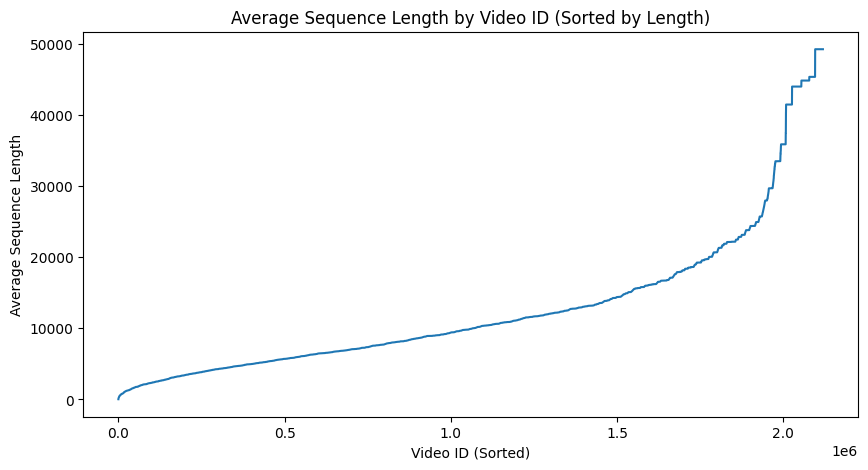

In [7]:
# 统计每个 video_id 的平均序列长度
video_id_avg_sequence_length = video_id_to_sequence_lengths.apply(lambda x: np.mean(x))

# 按序列长度升序排列后绘制图
sorted_avg_sequence_length = video_id_avg_sequence_length.sort_values().reset_index(drop=True)
plt.figure(figsize=(10, 5))
sorted_avg_sequence_length.plot(kind='line', title='Average Sequence Length by Video ID (Sorted by Length)')
plt.xlabel('Video ID (Sorted)')
plt.ylabel('Average Sequence Length')
plt.show()

In [6]:
video_id_avg_sequence_length

video_id
1          16041.000000
4           9494.375000
8           7817.000000
9           8920.000000
12         10877.000000
               ...     
4371886    23134.000000
4371894     9440.000000
4371896    14260.000000
4371898     9977.465116
4371899     4256.000000
Name: user_id, Length: 2119510, dtype: float64